In [382]:
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

from scipy.signal import welch
from scipy.stats import skew
from scipy.stats import kurtosis

from pandas.plotting import scatter_matrix

import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report


# Предобработка

## Структура каталогов

In [383]:
ROOT = Path(".")

for p in sorted(ROOT.glob("experiment*")):
    print(p)

experiment_bicycle
experiment_handphone_1
experiment_handphone_2
experiment_motorbike
experiment_pocketphone_1
experiment_pocketphone_2


## Функция очистки названий столбцов

In [384]:
def clean_columns(df):
    df = df.copy()

    df.columns = (
        df.columns
        .str.strip()
        .str.replace(" ", "", regex=False)
    )

    return df

## Функция чтения одного эксперимента

In [385]:
def load_experiment(exp_dir):
    exp_dir = Path(exp_dir)

    imu = pd.read_csv(exp_dir / "imu.csv")
    pressure = pd.read_csv(exp_dir / "pressure.csv")

    imu = clean_columns(imu)
    pressure = clean_columns(pressure)

    return imu, pressure

## Загрузим все эксперименты

In [386]:
experiments = {
    "motorbike": "two_wheels",
    "bicycle": "two_wheels",

    "handphone_1": "walking",
    "handphone_2": "walking",

    "pocketphone_1": "walking",
    "pocketphone_2": "walking",
}

## Загрузка данных

In [387]:
data = {}

for exp_name, label in experiments.items():

    folder = Path(f"experiment_{exp_name}")

    imu, pressure = load_experiment(folder)

    data[exp_name] = {
        "label": label,
        "imu": imu,
        "pressure": pressure
    }

    print(
        f"{exp_name:15s}",
        f"imu={len(imu):7d}",
        f"pressure={len(pressure):7d}"
    )

motorbike       imu=  27927 pressure=    260
bicycle         imu=  24517 pressure=    228
handphone_1     imu=  18320 pressure=    170
handphone_2     imu=  18424 pressure=    171
pocketphone_1   imu=  18468 pressure=    172
pocketphone_2   imu=  18720 pressure=    174


## Проверка на мусор

In [388]:
for name, exp in data.items():

    print("\n", "=" * 60)
    print(name)

    print("\nIMU")
    print(exp["imu"].info())

    print("\nPressure")
    print(exp["pressure"].info())


motorbike

IMU
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27927 entries, 0 to 27926
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   t_utc[s]    27927 non-null  float64
 1   a_x[m/s2]   27927 non-null  float64
 2   a_y[m/s2]   27927 non-null  float64
 3   a_z[m/s2]   27927 non-null  float64
 4   w_x[rad/s]  27927 non-null  float64
 5   w_y[rad/s]  27927 non-null  float64
 6   w_z[rad/s]  27927 non-null  float64
dtypes: float64(7)
memory usage: 1.5 MB
None

Pressure
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260 entries, 0 to 259
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   t_utc[s]            260 non-null    float64
 1   pressure[millibar]  260 non-null    float64
dtypes: float64(2)
memory usage: 4.2 KB
None

bicycle

IMU
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24517 entries, 0 to 24516
Data columns (tot

### Проверка NaN

In [389]:
for name, exp in data.items():

    imu_nan = exp["imu"].isna().sum().sum()
    pressure_nan = exp["pressure"].isna().sum().sum()

    print(
        f"{name:15s} "
        f"imu_nan={imu_nan} "
        f"pressure_nan={pressure_nan}"
    )

motorbike       imu_nan=0 pressure_nan=0
bicycle         imu_nan=0 pressure_nan=0
handphone_1     imu_nan=0 pressure_nan=0
handphone_2     imu_nan=0 pressure_nan=0
pocketphone_1   imu_nan=0 pressure_nan=0
pocketphone_2   imu_nan=0 pressure_nan=0


## Проверим временные метки

In [390]:
for name, exp in data.items():

    imu = exp["imu"]

    dt = np.diff(imu["t_utc[s]"])

    print(
        f"{name:15s}",
        f"dt_mean={dt.mean():.4f}",
        f"freq={1/dt.mean():.2f} Hz"
    )

motorbike       dt_mean=0.0100 freq=100.00 Hz
bicycle         dt_mean=0.0100 freq=100.00 Hz
handphone_1     dt_mean=0.0100 freq=100.00 Hz
handphone_2     dt_mean=0.0100 freq=100.00 Hz
pocketphone_1   dt_mean=0.0100 freq=100.00 Hz
pocketphone_2   dt_mean=0.0100 freq=100.00 Hz


## Посмотрим на давление

In [391]:
for name, exp in data.items():

    pressure = exp["pressure"]

    dt = np.diff(pressure["t_utc[s]"])

    print(
        f"{name:15s}",
        f"dt_mean={dt.mean():.3f}",
        f"freq={1/dt.mean():.2f} Hz"
    )

motorbike       dt_mean=1.068 freq=0.94 Hz
bicycle         dt_mean=1.067 freq=0.94 Hz
handphone_1     dt_mean=1.066 freq=0.94 Hz
handphone_2     dt_mean=1.066 freq=0.94 Hz
pocketphone_1   dt_mean=1.066 freq=0.94 Hz
pocketphone_2   dt_mean=1.066 freq=0.94 Hz


## Модуль ускорения

In [392]:
for exp in data.values():

    imu = exp["imu"]

    imu["acc_norm"] = np.sqrt(
        imu["a_x[m/s2]"]**2 +
        imu["a_y[m/s2]"]**2 +
        imu["a_z[m/s2]"]**2
    )

    imu["gyro_norm"] = np.sqrt(
        imu["w_x[rad/s]"]**2 +
        imu["w_y[rad/s]"]**2 +
        imu["w_z[rad/s]"]**2
    )

## Быстрая визуализация

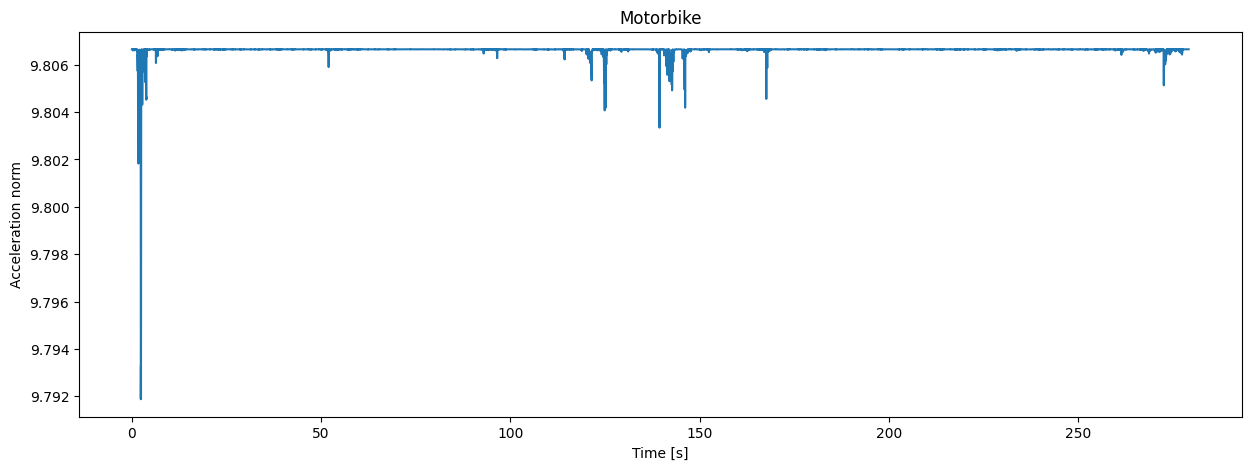

In [393]:
fig, ax = plt.subplots(figsize=(15, 5))

imu = data["motorbike"]["imu"]

ax.plot(
    imu["t_utc[s]"] - imu["t_utc[s]"].iloc[0],
    imu["acc_norm"]
)

ax.set_title("Motorbike")
ax.set_xlabel("Time [s]")
ax.set_ylabel("Acceleration norm")
plt.show()

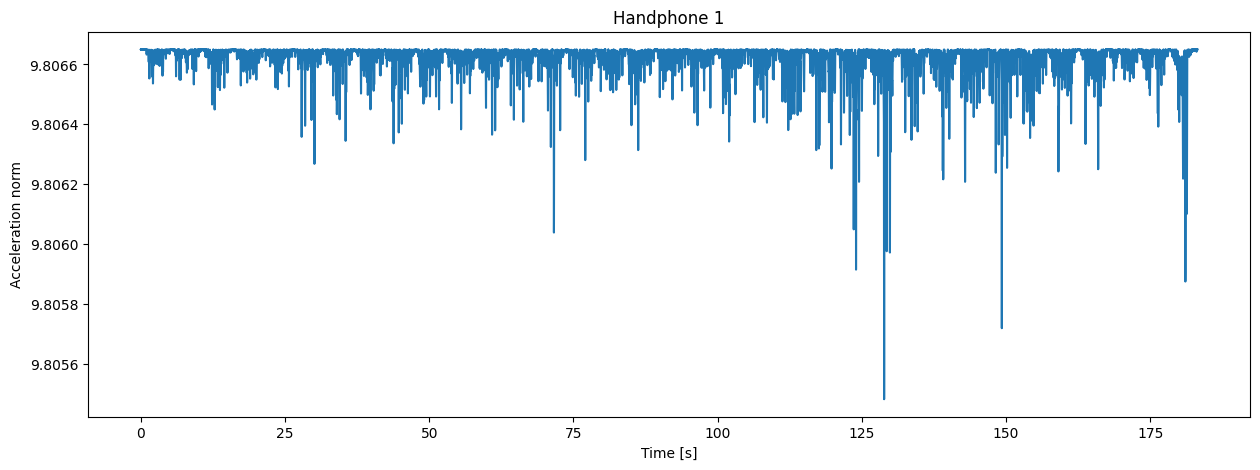

In [394]:
fig, ax = plt.subplots(figsize=(15, 5))

imu = data["handphone_1"]["imu"]

ax.plot(
    imu["t_utc[s]"] - imu["t_utc[s]"].iloc[0],
    imu["acc_norm"]
)

ax.set_title("Handphone 1")
ax.set_xlabel("Time [s]")
ax.set_ylabel("Acceleration norm")
plt.show()

In [395]:
data

{'motorbike': {'label': 'two_wheels',
  'imu':            t_utc[s]  a_x[m/s2]  a_y[m/s2]  a_z[m/s2]  w_x[rad/s]  w_y[rad/s]  \
  0      1.781258e+09  -1.855296  -4.674409  -8.418917   -0.213083   -0.434289   
  1      1.781258e+09  -1.884948  -4.659474  -8.420609   -0.198745   -0.412741   
  2      1.781258e+09  -1.912849  -4.645935  -8.421798   -0.181029   -0.391855   
  3      1.781258e+09  -1.938941  -4.633634  -8.422608   -0.172617   -0.371284   
  4      1.781258e+09  -1.964153  -4.622012  -8.423151   -0.165601   -0.377050   
  ...             ...        ...        ...        ...         ...         ...   
  27922  1.781258e+09  -0.093189  -6.192937  -7.603238   -0.084775   -0.203295   
  27923  1.781258e+09  -0.110815  -6.187866  -7.607127   -0.040490   -0.264275   
  27924  1.781258e+09  -0.129711  -6.188507  -7.606307    0.061593   -0.182681   
  27925  1.781258e+09  -0.141780  -6.195759  -7.600186    0.120481   -0.078277   
  27926  1.781258e+09  -0.143062  -6.196674  -7.59941

## Анализ данных

### Посмотрим длительность экспериментов

In [396]:
for name, exp in data.items():

    imu = exp["imu"]

    duration = (
        imu["t_utc[s]"].iloc[-1]
        - imu["t_utc[s]"].iloc[0]
    )

    print(
        f"{name:15s}",
        f"{duration:.1f} sec"
    )

motorbike       279.3 sec
bicycle         245.2 sec
handphone_1     183.2 sec
handphone_2     184.2 sec
pocketphone_1   184.7 sec
pocketphone_2   187.2 sec


### Нормализуем время

In [397]:
for exp in data.values():

    imu = exp["imu"]
    pressure = exp["pressure"]

    imu["t"] = imu["t_utc[s]"] - imu["t_utc[s]"].iloc[0]
    pressure["t"] = pressure["t_utc[s]"] - pressure["t_utc[s]"].iloc[0]

### Визуально сравним сигналы

In [398]:
def plot_signal(exp_name, seconds=20):

    imu = data[exp_name]["imu"]

    mask = imu["t"] < seconds

    plt.figure(figsize=(15,5))

    plt.plot(
        imu.loc[mask, "t"],
        imu.loc[mask, "acc_norm"]
    )

    plt.title(exp_name)
    plt.xlabel("Time [s]")
    plt.ylabel("Acceleration norm")

    plt.grid(True)
    plt.show()

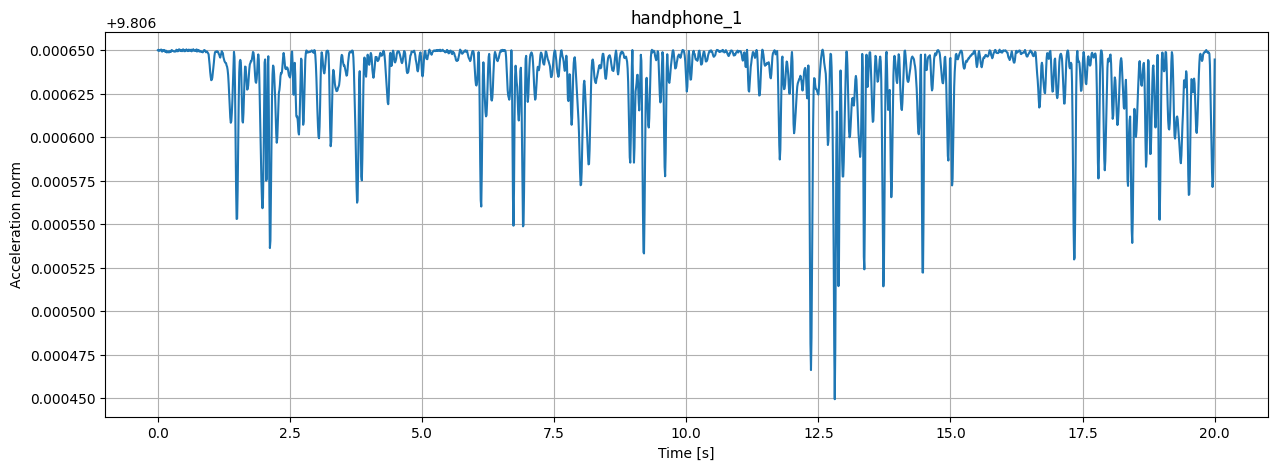

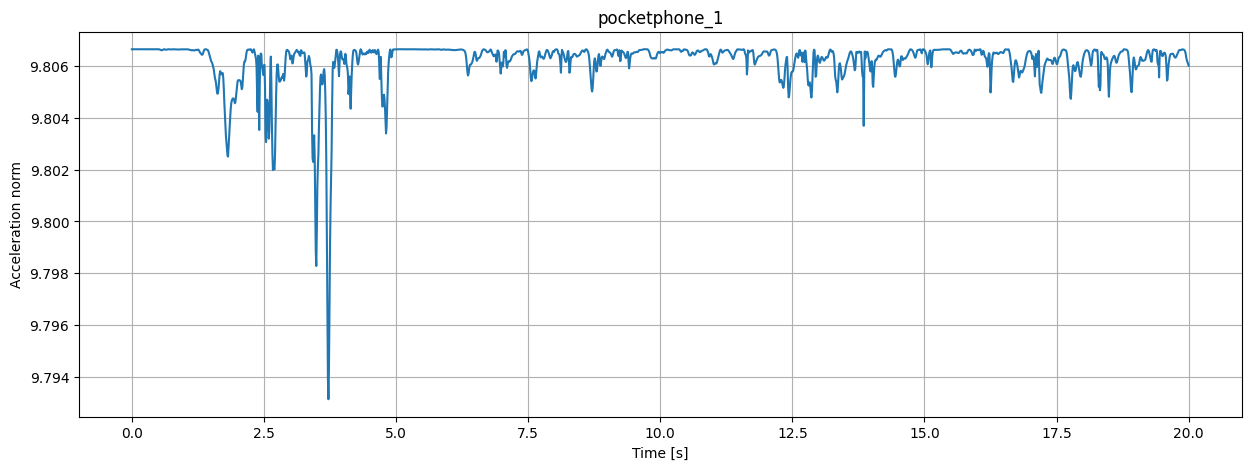

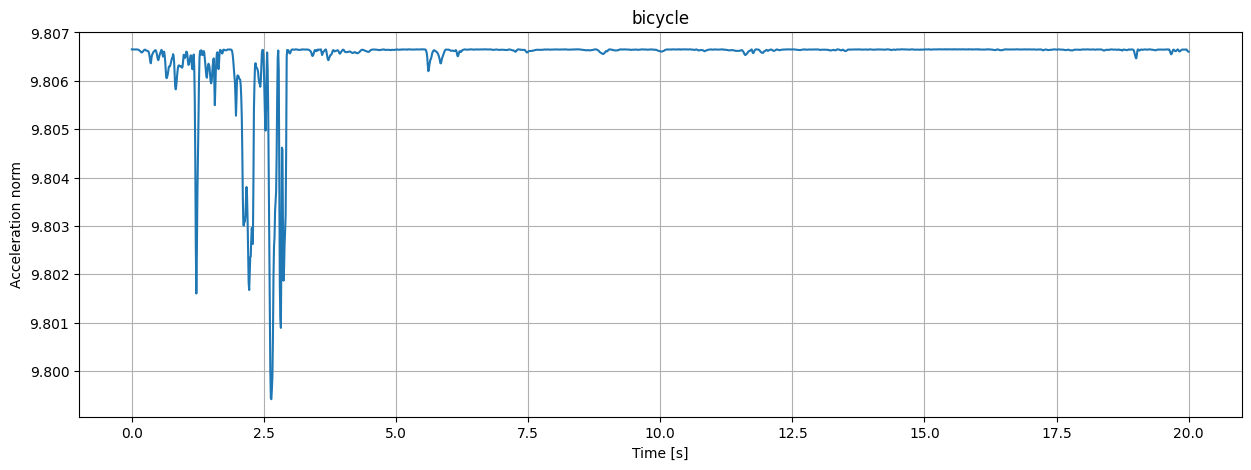

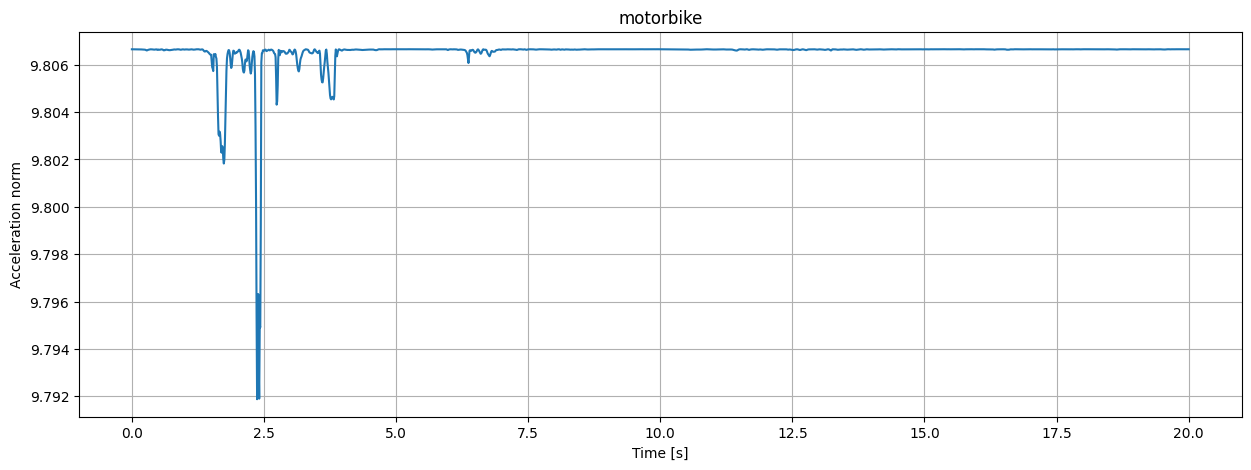

In [399]:
plot_signal("handphone_1")
plot_signal("pocketphone_1")
plot_signal("bicycle")
plot_signal("motorbike")

### Посмотрим спектры

In [400]:
def plot_spectrum(exp_name):

    imu = data[exp_name]["imu"]

    fs = 100

    f, pxx = welch(
        imu["acc_norm"],
        fs=fs,
        nperseg=2048
    )

    plt.figure(figsize=(10,5))

    plt.semilogy(f, pxx)

    plt.title(exp_name)
    plt.xlabel("Frequency [Hz]")
    plt.ylabel("PSD")

    plt.grid(True)

    plt.show()

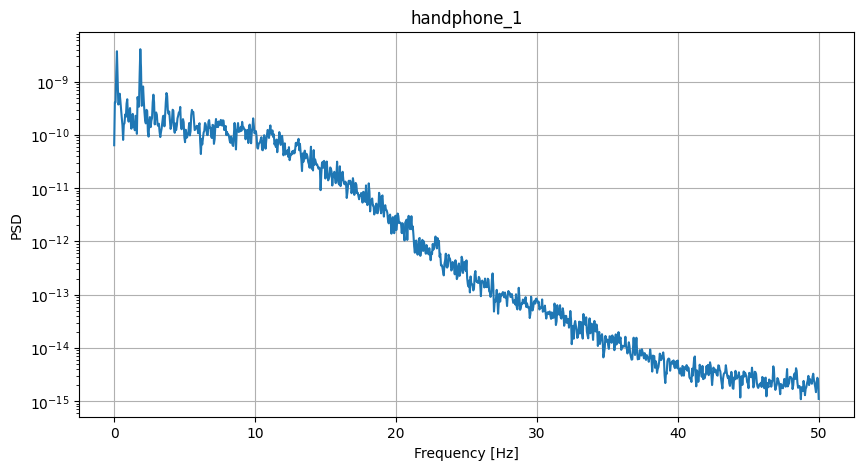

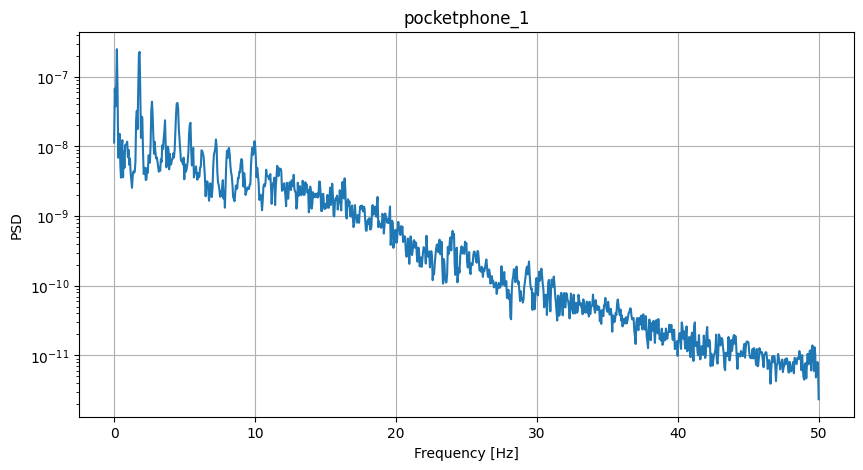

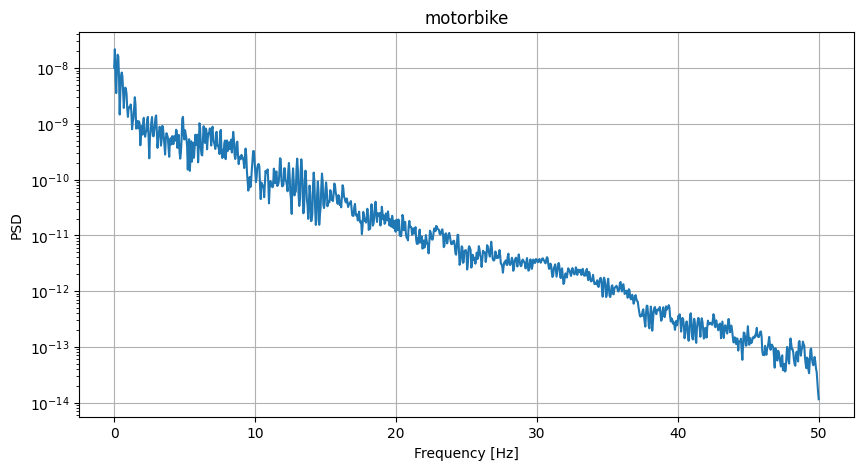

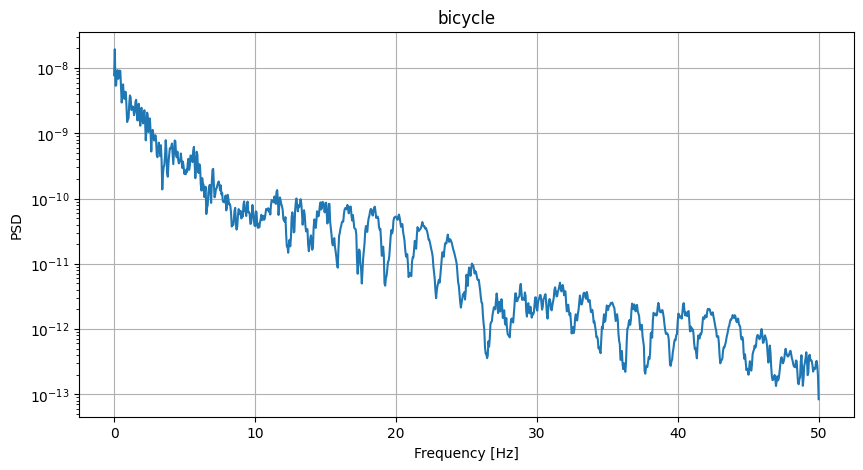

In [401]:
plot_spectrum("handphone_1")
plot_spectrum("pocketphone_1")
plot_spectrum("motorbike")
plot_spectrum("bicycle")

### Разбиваем на окна

In [402]:
WINDOW_SIZE = 500
STEP_SIZE = 100

### Извлекаем признаки

In [403]:
def extract_features(window):

    x = window["acc_norm"].values

    return {
        "acc_mean": np.mean(x),
        "acc_std": np.std(x),
        "acc_min": np.min(x),
        "acc_max": np.max(x),
        "acc_range": np.ptp(x),
        "acc_skew": skew(x),
        "acc_kurtosis": kurtosis(x),
        "acc_rms": np.sqrt(np.mean(x**2))
    }

### Формируем датасет окон

In [404]:
rows = []

for exp_name, exp in data.items():

    imu = exp["imu"]

    for start in range(
        0,
        len(imu) - WINDOW_SIZE,
        STEP_SIZE
    ):

        stop = start + WINDOW_SIZE

        window = imu.iloc[start:stop]

        feat = extract_features(window)

        feat["experiment"] = exp_name
        feat["label"] = exp["label"]

        rows.append(feat)

dataset = pd.DataFrame(rows)

In [405]:
dataset.head()

,acc_mean,acc_std,acc_min,acc_max,acc_range,acc_skew,acc_kurtosis,acc_rms,experiment,label
0,9.806109,0.001771,9.791876,9.806651,0.014775,-5.610513,34.956576,9.806109,motorbike,two_wheels
1,9.806112,0.001771,9.791876,9.806652,0.014776,-5.607519,34.926764,9.806112,motorbike,two_wheels
2,9.806250,0.001664,9.791876,9.806652,0.014776,-6.733861,47.290533,9.806250,motorbike,two_wheels
3,9.806538,0.000336,9.804532,9.806652,0.002121,-4.425365,20.253386,9.806538,motorbike,two_wheels
4,9.806630,0.000051,9.806071,9.806652,0.000582,-5.827707,44.750963,9.806630,motorbike,two_wheels


### Смотрим разделимость признаков

In [406]:
dataset.groupby("label")[
    ["acc_std", "acc_range", "acc_rms"]
].mean()

,acc_std,acc_range,acc_rms
label,,,
two_wheels,0.000064,0.000492,9.806624
walking,0.000214,0.001576,9.806492


### Быстрая визуализация

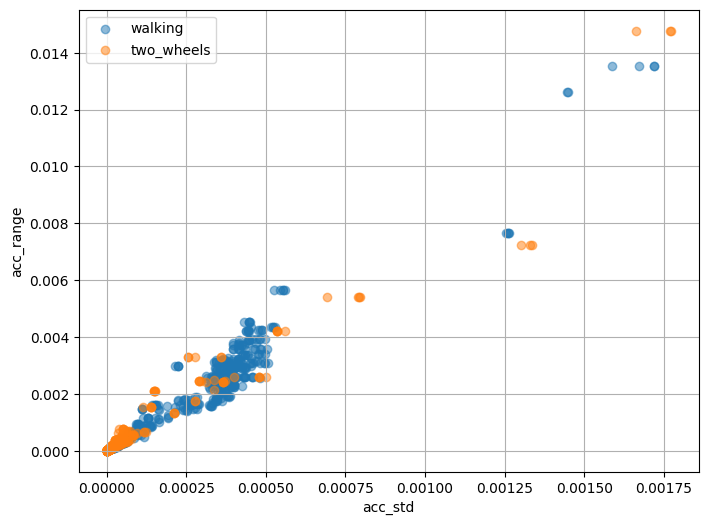

In [407]:
walking = dataset[
    dataset.label == "walking"
]

two_wheels = dataset[
    dataset.label == "two_wheels"
]

plt.figure(figsize=(8,6))

plt.scatter(
    walking["acc_std"],
    walking["acc_range"],
    alpha=0.5,
    label="walking"
)

plt.scatter(
    two_wheels["acc_std"],
    two_wheels["acc_range"],
    alpha=0.5,
    label="two_wheels"
)

plt.xlabel("acc_std")
plt.ylabel("acc_range")

plt.legend()
plt.grid(True)

plt.show()

### Убрать гравитацию

In [408]:
for exp in data.values():

    imu = exp["imu"]

    imu["acc_dyn"] = (
        imu["acc_norm"]
        - imu["acc_norm"].rolling(
            200,
            center=True,
            min_periods=1
        ).mean()
    )

### Посмотреть новый сигнал

In [409]:
def plot_dynamic(exp_name, seconds=20):

    imu = data[exp_name]["imu"]

    mask = imu["t"] < seconds

    plt.figure(figsize=(15,4))

    plt.plot(
        imu.loc[mask, "t"],
        imu.loc[mask, "acc_dyn"]
    )

    plt.grid()
    plt.title(exp_name)
    plt.show()

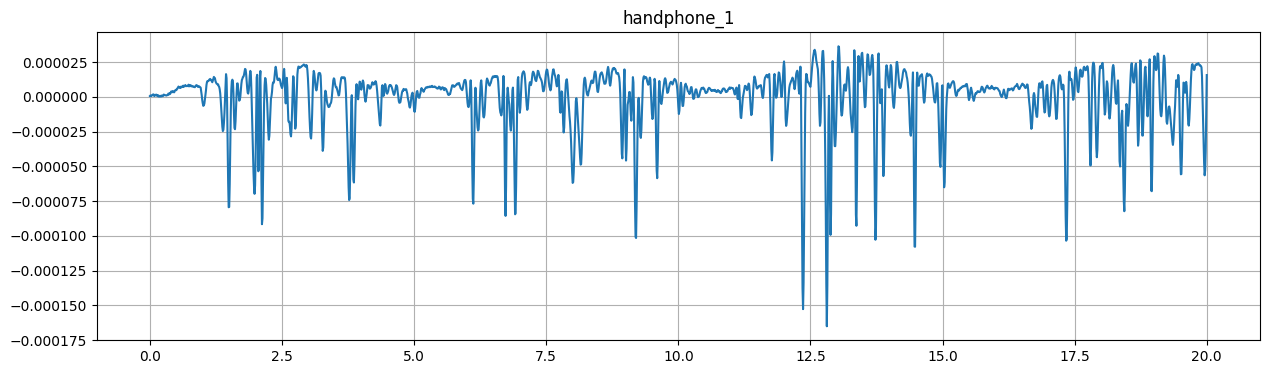

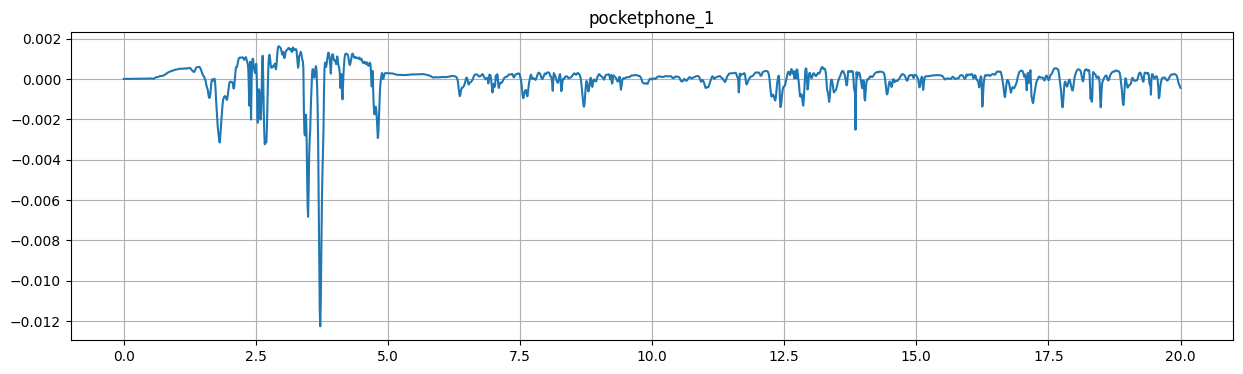

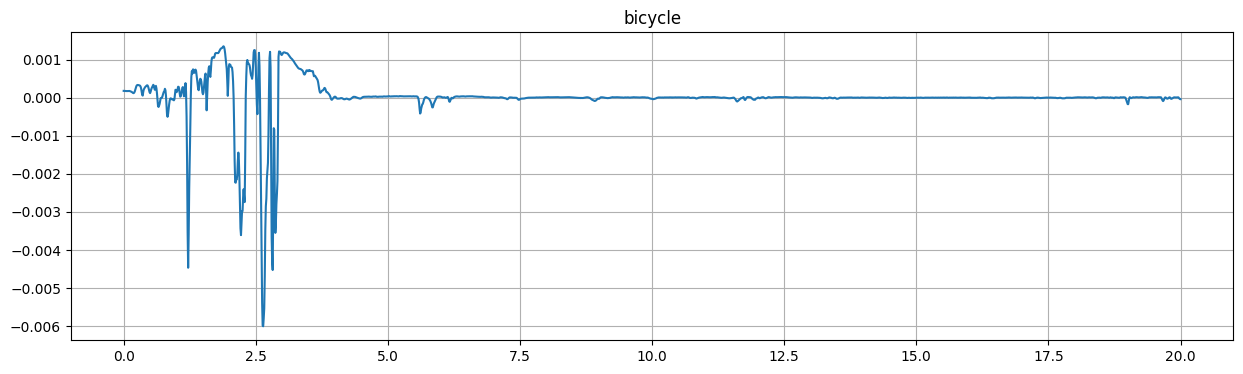

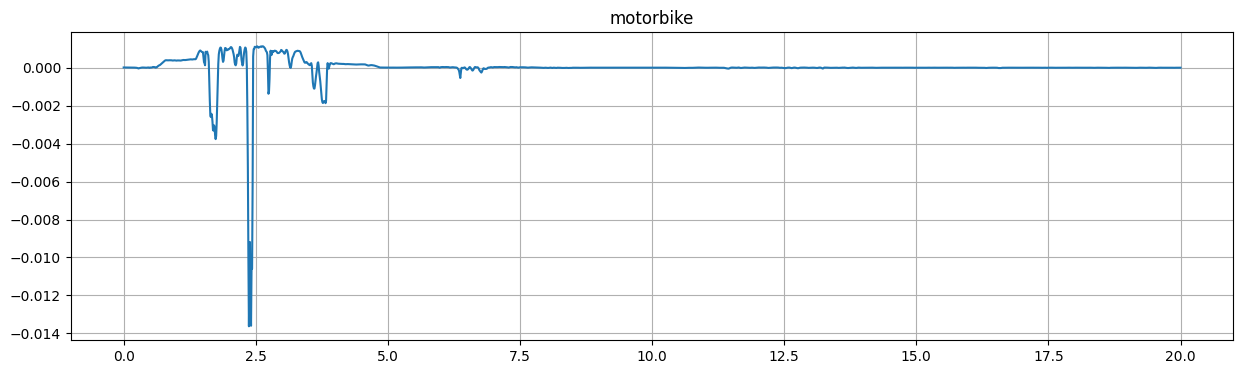

In [410]:
plot_dynamic("handphone_1")
plot_dynamic("pocketphone_1")
plot_dynamic("bicycle")
plot_dynamic("motorbike")

### Проанализируем изменённые данные

In [411]:
def plot_spectrum(exp_name):

    imu = data[exp_name]["imu"]

    fs = 100

    f, pxx = welch(
        imu["acc_dyn"],
        fs=fs,
        nperseg=2048
    )

    plt.figure(figsize=(10,5))

    plt.semilogy(f, pxx)

    plt.title(exp_name)
    plt.xlabel("Frequency [Hz]")
    plt.ylabel("PSD")

    plt.grid(True)

    plt.show()

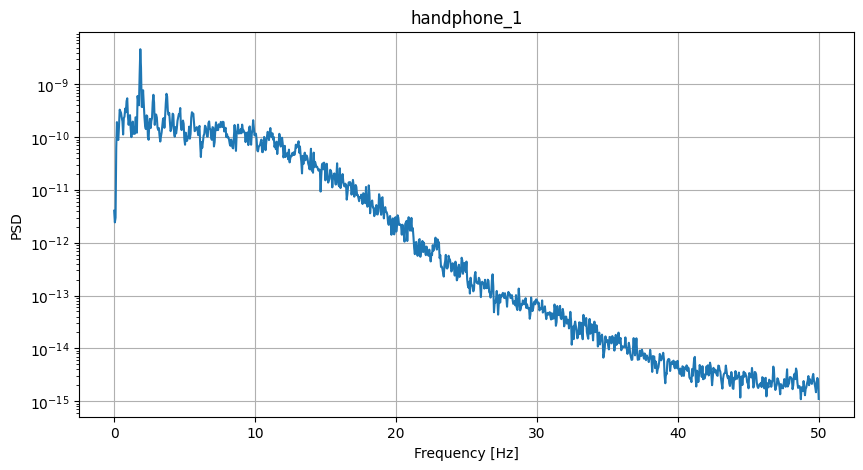

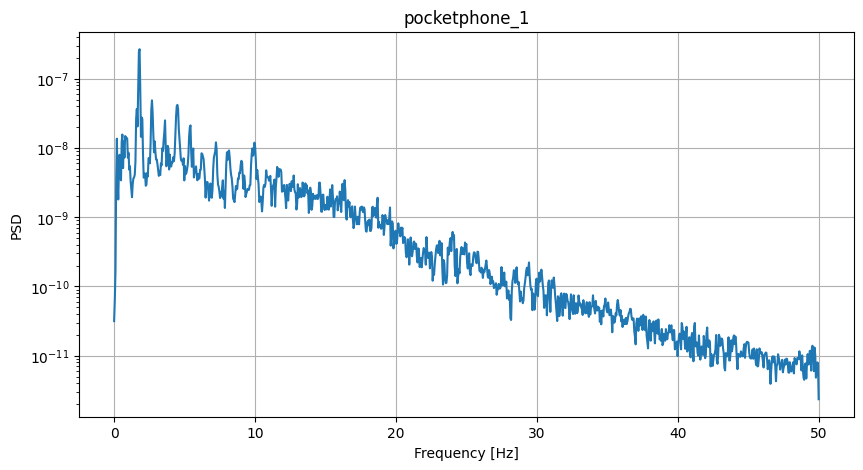

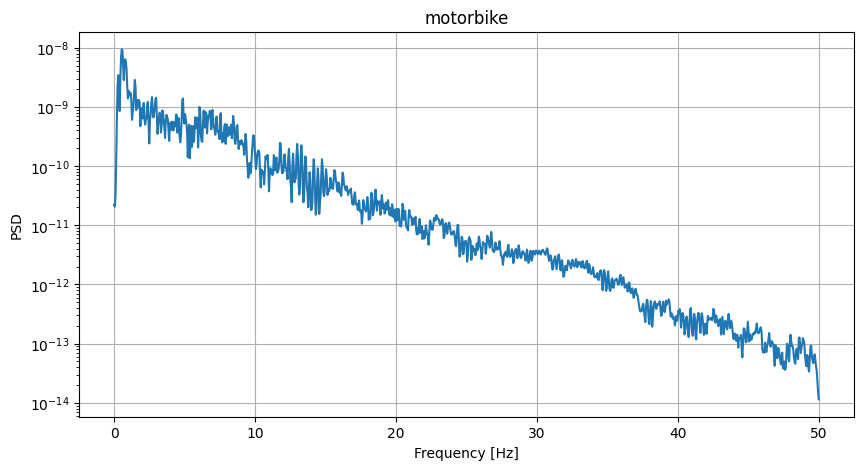

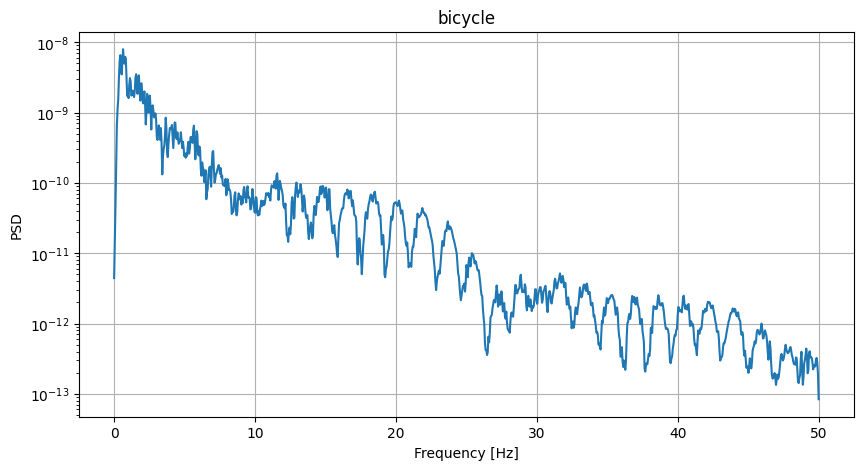

In [412]:
plot_spectrum("handphone_1")
plot_spectrum("pocketphone_1")
plot_spectrum("motorbike")
plot_spectrum("bicycle")

## Посмотрим гироскоп

In [413]:
def plot_gyro(exp_name, seconds=20):

    imu = data[exp_name]["imu"]

    mask = imu["t"] < seconds

    plt.figure(figsize=(15,4))

    plt.plot(
        imu.loc[mask, "t"],
        imu.loc[mask, "gyro_norm"]
    )

    plt.grid()
    plt.title(exp_name)
    plt.show()

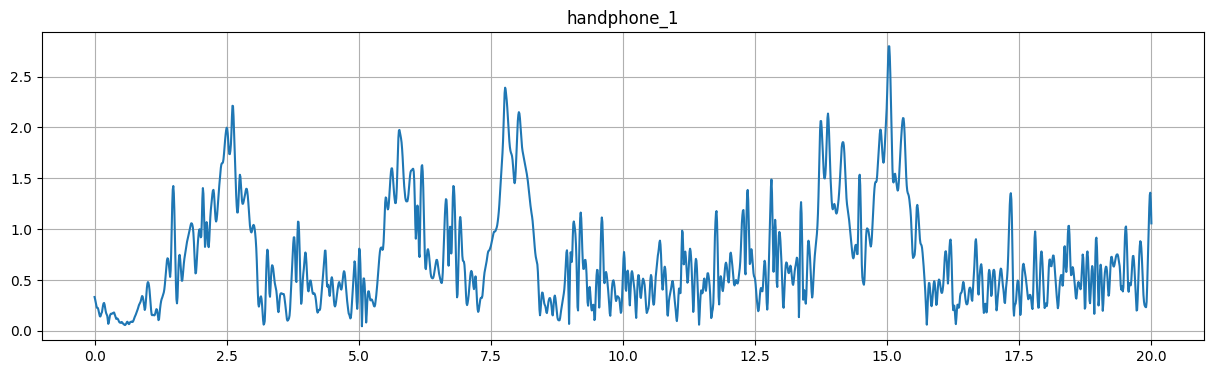

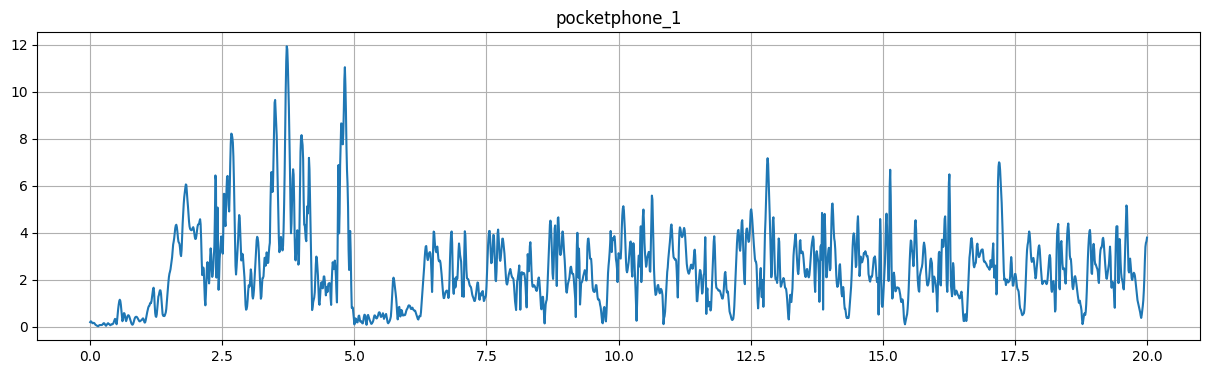

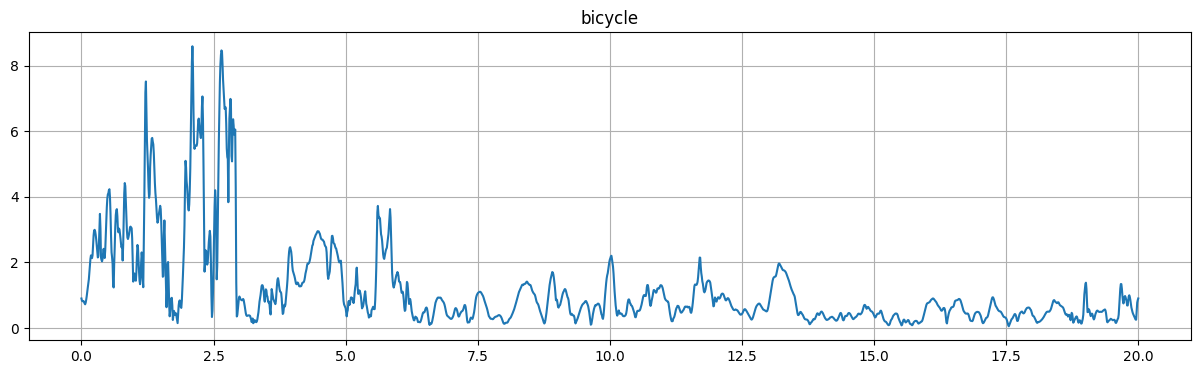

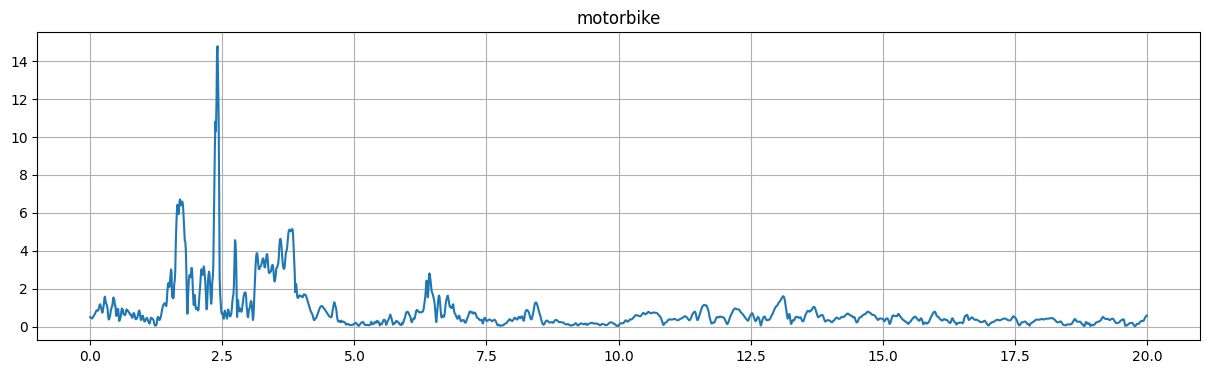

In [414]:
plot_gyro("handphone_1")
plot_gyro("pocketphone_1")
plot_gyro("bicycle")
plot_gyro("motorbike")

### Пересоберём датасет, добавим новые признаки

In [415]:
FS = 100

def extract_features(window):

    x = window["acc_dyn"].values

    features = {}

    # Временная область
    features["acc_mean"] = np.mean(x)
    features["acc_std"] = np.std(x)
    features["acc_rms"] = np.sqrt(np.mean(x**2))
    features["acc_range"] = np.ptp(x)

    # Спектр
    f, pxx = welch(
        x,
        fs=FS,
        nperseg=min(len(x), 512)
    )

    features["spectral_energy"] = np.sum(pxx)

    # Доминирующая частота
    features["dominant_freq"] = f[np.argmax(pxx)]

    # Энергия шагов
    step_band = (f >= 1) & (f <= 3)

    features["energy_1_3Hz"] = np.sum(pxx[step_band])

    # Высокочастотная энергия
    high_band = (f >= 10)

    features["energy_10Hz+"] = np.sum(pxx[high_band])

    return features

In [416]:
rows = []

for exp_name, exp in data.items():

    imu = exp["imu"]

    for start in range(
        0,
        len(imu) - WINDOW_SIZE,
        STEP_SIZE
    ):

        stop = start + WINDOW_SIZE

        window = imu.iloc[start:stop]

        feat = extract_features(window)

        feat["experiment"] = exp_name
        feat["label"] = exp["label"]

        rows.append(feat)

dataset = pd.DataFrame(rows)

print(dataset.shape)
dataset.head()

(1238, 10)


,acc_mean,acc_std,acc_rms,acc_range,spectral_energy,dominant_freq,energy_1_3Hz,energy_10Hz+,experiment,label
0,0.000002,0.001688,0.001688,0.014759,3.462488e-05,1.4,1.641453e-05,1.752895e-06,motorbike,two_wheels
1,-0.000019,0.001686,0.001686,0.014759,1.307460e-05,0.8,5.405906e-06,6.770391e-07,motorbike,two_wheels
2,-0.000035,0.001586,0.001586,0.014759,1.061026e-06,0.8,3.758784e-07,3.701314e-08,motorbike,two_wheels
3,0.000042,0.000360,0.000362,0.002810,8.196201e-08,0.8,2.575945e-08,4.433896e-09,motorbike,two_wheels
4,0.000028,0.000080,0.000084,0.000772,3.418782e-08,0.2,4.849945e-09,4.807865e-09,motorbike,two_wheels


### Новый scatter

In [417]:
def plot_features(x_col, y_col):

    plt.figure(figsize=(8, 6))

    for label in dataset["label"].unique():

        subset = dataset[
            dataset["label"] == label
        ]

        plt.scatter(
            subset[x_col],
            subset[y_col],
            alpha=0.6,
            label=label
        )

    plt.xlabel(x_col)
    plt.ylabel(y_col)

    plt.legend()
    plt.grid(True)

    plt.show()

### Попарно отрисуем признаки и попытаемся найти лучшее разделение

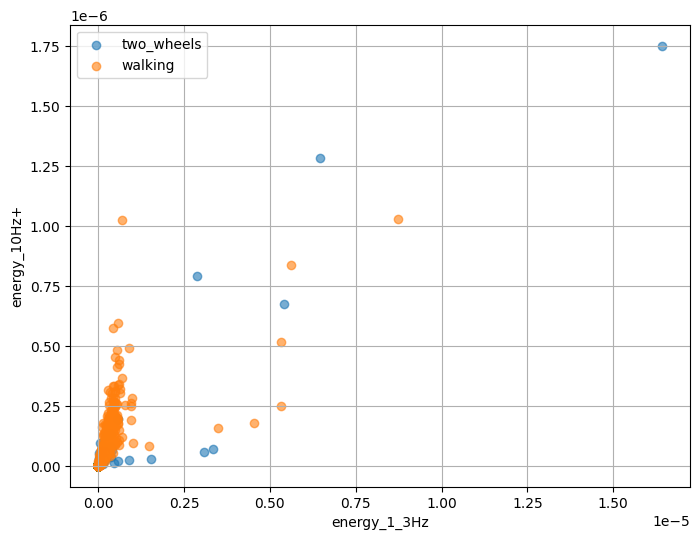

In [418]:
plot_features(
    "energy_1_3Hz",
    "energy_10Hz+"
)

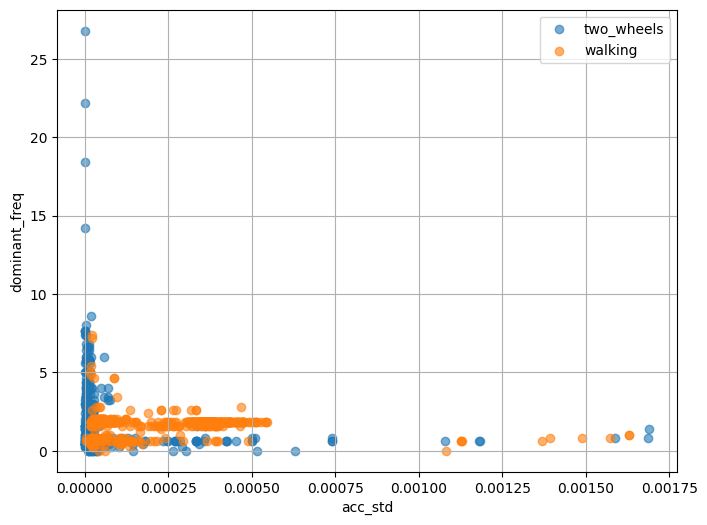

In [419]:
plot_features(
    "acc_std",
    "dominant_freq"
)

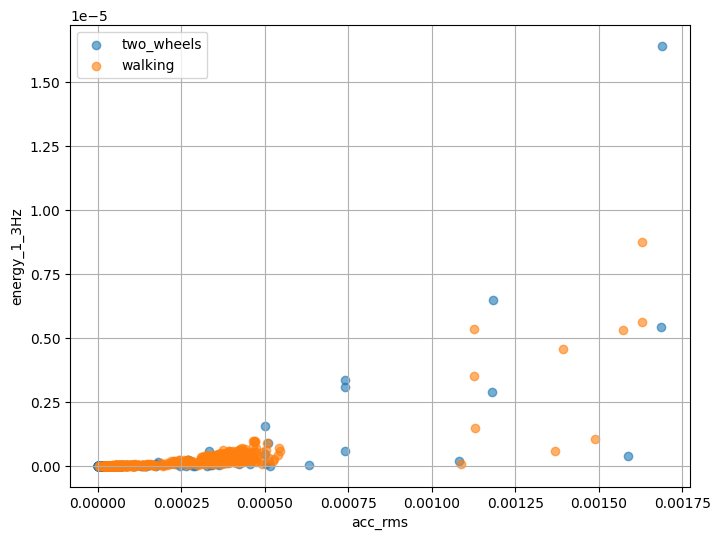

In [420]:
plot_features(
    "acc_rms",
    "energy_1_3Hz"
)

### Посмотрим вообще всё

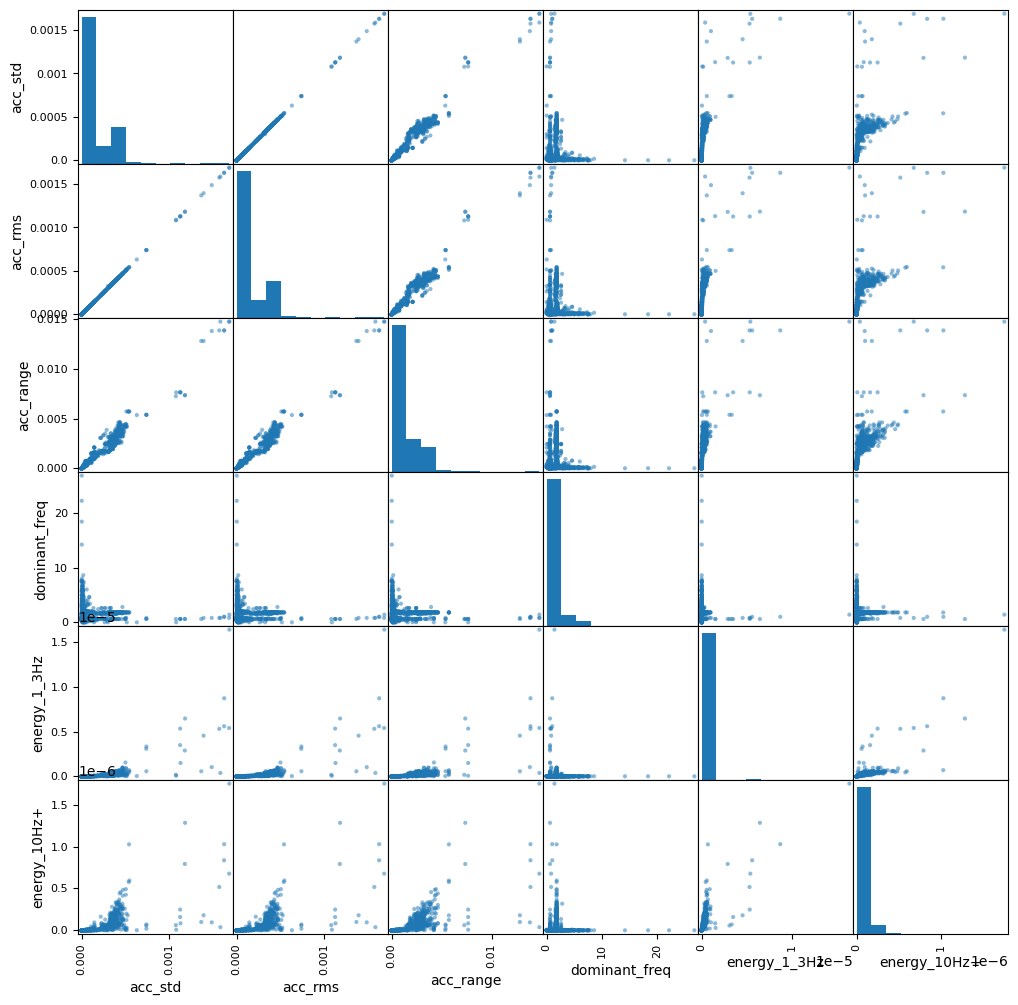

In [421]:
cols = [
    "acc_std",
    "acc_rms",
    "acc_range",
    "dominant_freq",
    "energy_1_3Hz",
    "energy_10Hz+"
]

scatter_matrix(
    dataset[cols],
    figsize=(12, 12),
    diagonal="hist"
)

plt.show()

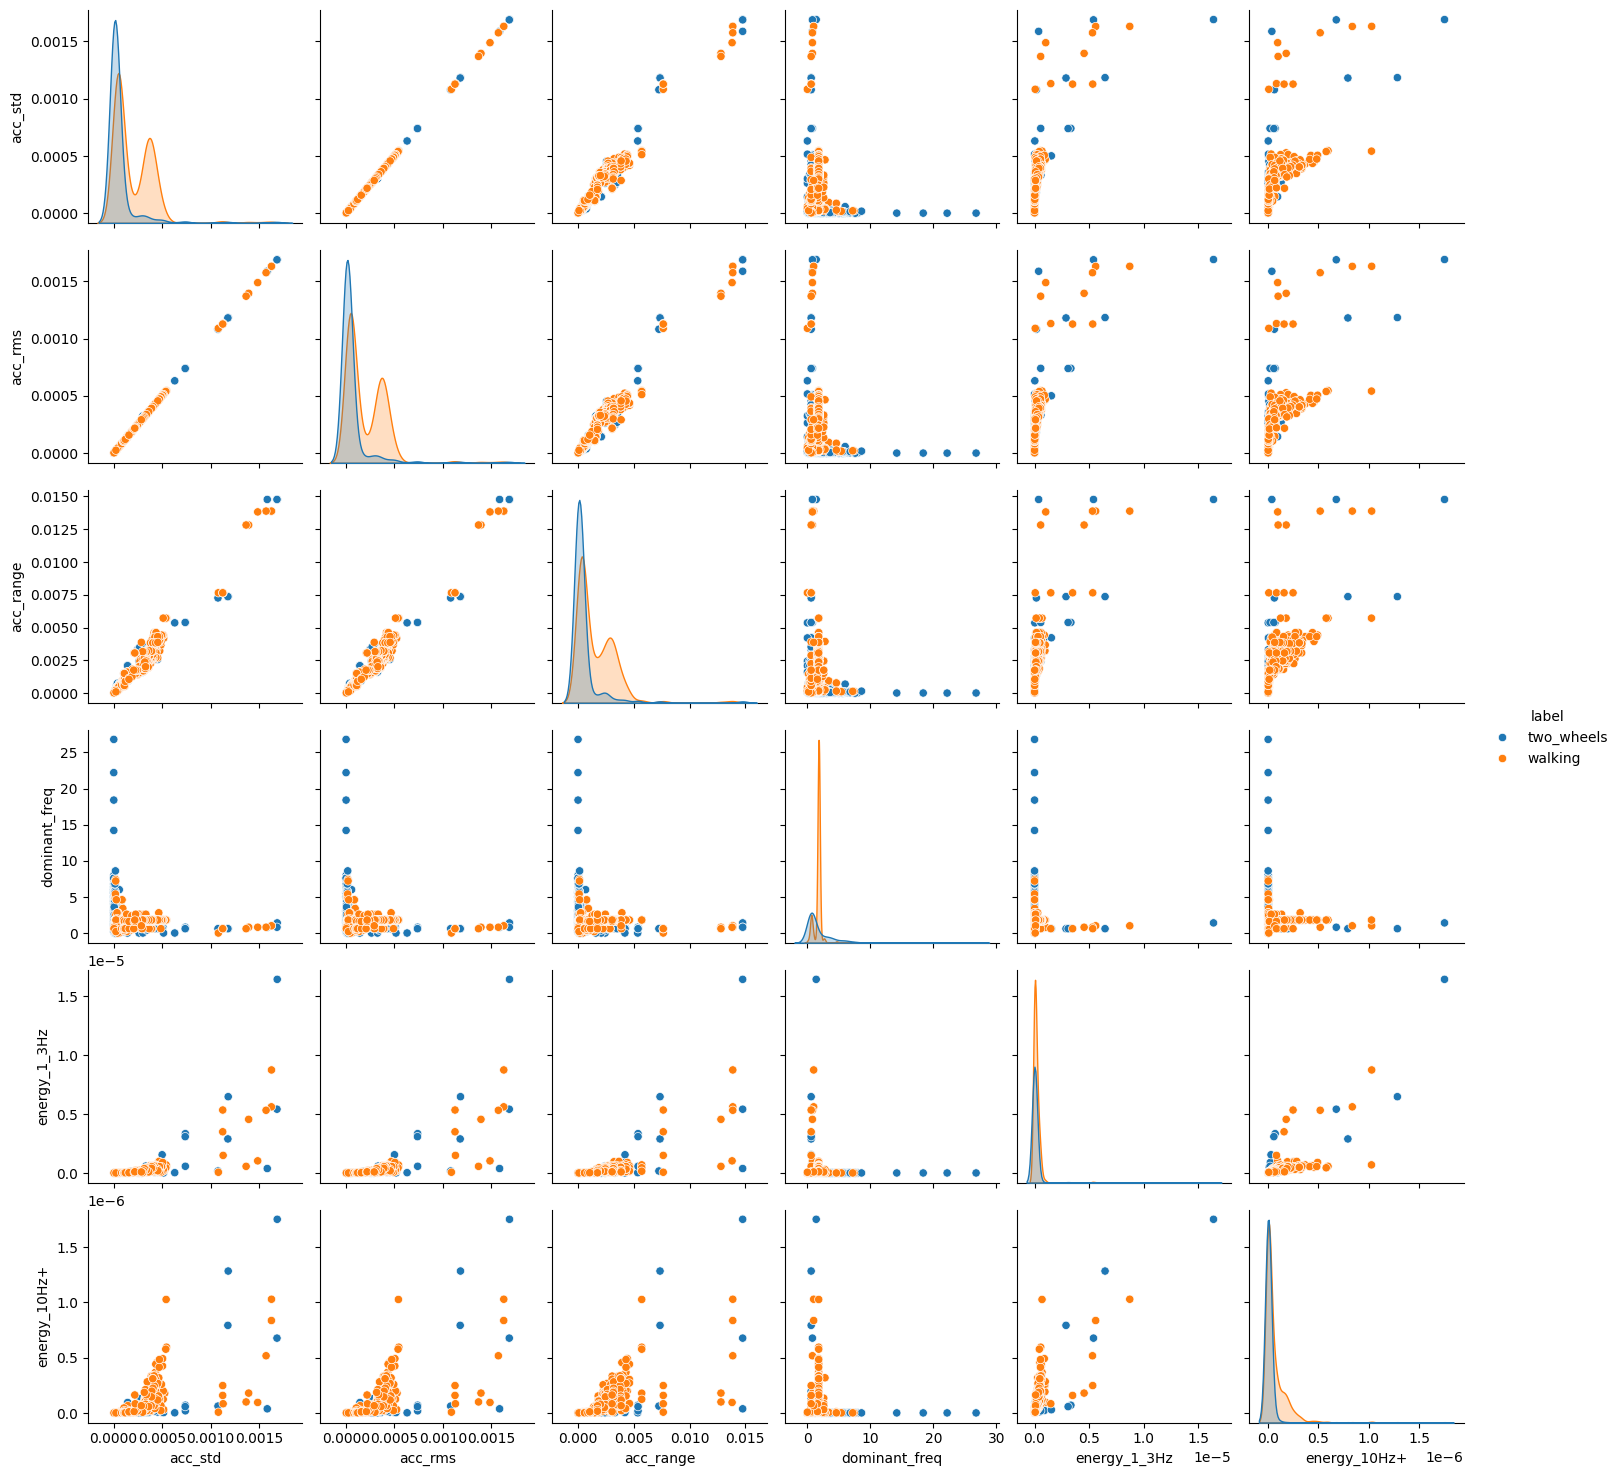

In [422]:
sns.pairplot(
    dataset[
        cols + ["label"]
    ],
    hue="label"
)

plt.show()

## Тяжело

### Подготовка данных

In [423]:
X = dataset.drop(
    columns=["label", "experiment"]
)

y = dataset["label"]

### Преобразуем метки классов в числа

In [424]:
le = LabelEncoder()

y_encoded = le.fit_transform(y)

print(dict(zip(le.classes_, le.transform(le.classes_))))

{'two_wheels': np.int64(0), 'walking': np.int64(1)}


### Обучаем Random Forest

In [425]:
rf = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)

rf.fit(X, y_encoded)

,n_estimators,500
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### Извлекаем важность признаков

In [426]:
importance = pd.DataFrame({
    "feature": X.columns,
    "importance": rf.feature_importances_
})

importance = importance.sort_values(
    "importance",
    ascending=False
)

importance

,feature,importance
7,energy_10Hz+,0.186462
5,dominant_freq,0.154689
2,acc_rms,0.153156
1,acc_std,0.142789
6,energy_1_3Hz,0.122340
4,spectral_energy,0.120176
3,acc_range,0.085944
0,acc_mean,0.034443


### Визуализация

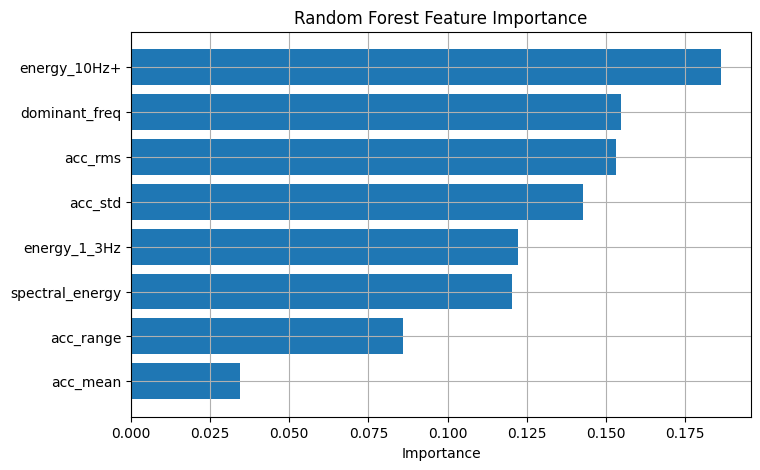

In [427]:
plt.figure(figsize=(8,5))

plt.barh(
    importance["feature"],
    importance["importance"]
)

plt.gca().invert_yaxis()

plt.xlabel("Importance")
plt.title("Random Forest Feature Importance")

plt.grid(True)

plt.show()

### Проверка качества классификации

In [428]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.3,
    random_state=42,
    stratify=y_encoded
)

rf = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

pred = rf.predict(X_test)

print(
    classification_report(
        y_test,
        pred,
        target_names=le.classes_
    )
)

              precision    recall  f1-score   support

  two_wheels       0.90      0.95      0.93       155
     walking       0.97      0.92      0.94       217

    accuracy                           0.94       372
   macro avg       0.93      0.94      0.93       372
weighted avg       0.94      0.94      0.94       372



### Ого

#### А теперь посмотрим важность признаков

In [430]:
importance.head(20)

,feature,importance
7,energy_10Hz+,0.186462
5,dominant_freq,0.154689
2,acc_rms,0.153156
1,acc_std,0.142789
6,energy_1_3Hz,0.122340
4,spectral_energy,0.120176
3,acc_range,0.085944
0,acc_mean,0.034443


### Матрица корреляций, точно! Почему я не сделал этого раньше...

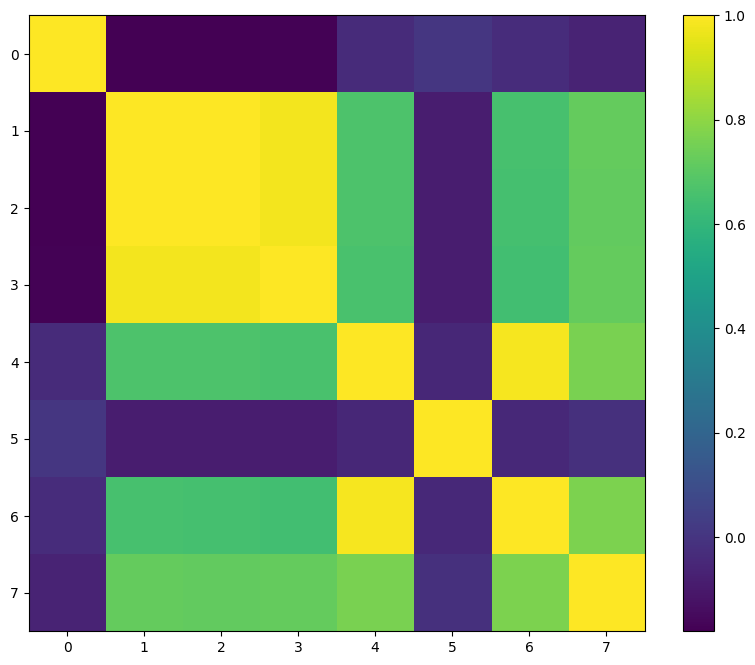

In [431]:
corr = dataset.drop(
    columns=["label", "experiment"]
).corr()

plt.figure(figsize=(10,8))
plt.imshow(corr)
plt.colorbar()
plt.show()

### Проверим разделимость

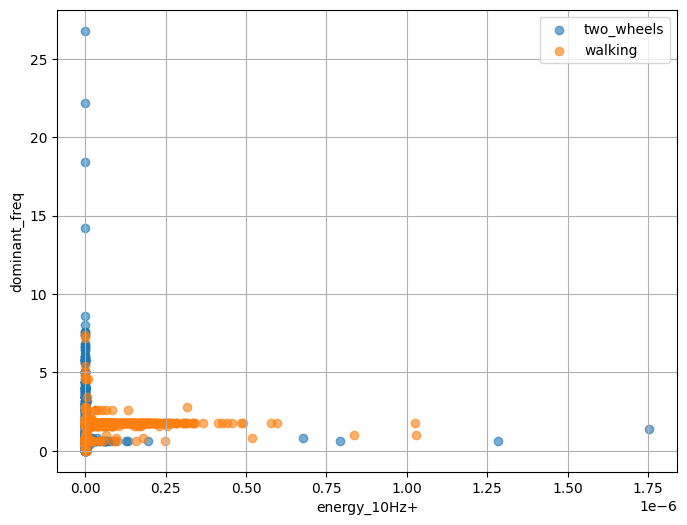

In [432]:
plot_features(
    "energy_10Hz+",
    "dominant_freq"
)

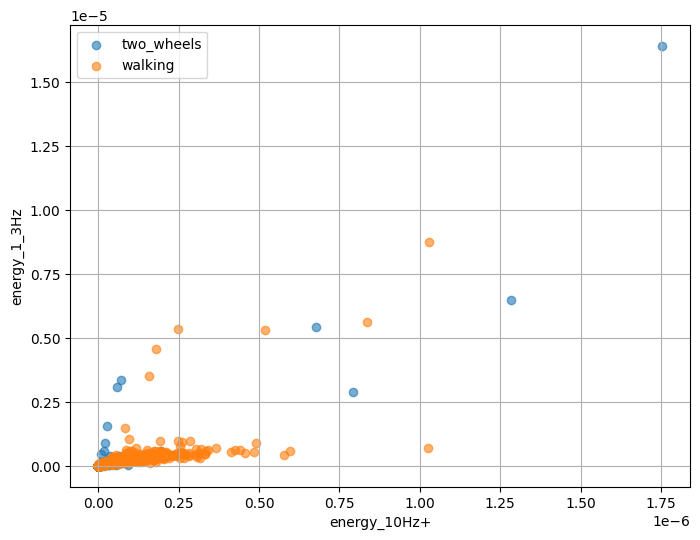

In [433]:
plot_features(
    "energy_10Hz+",
    "energy_1_3Hz"
)